<a href="https://colab.research.google.com/github/jhurley-blip/ECE4580/blob/main/ECE4580_CNN_ClassExample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECE 4580 — Computer Vision
## Class Example: Convolutional Neural Networks in PyTorch
### Georgia Institute of Technology

---

**Purpose:** This notebook walks through every concept you will need for Homework 4, step by step, with detailed explanations. Work through it top-to-bottom before starting the assignment.

**Topics Covered:**
1. [Setup & GPU Verification](#setup)
2. [Loading & Visualizing CIFAR-10](#data)
3. [Data Augmentation](#augmentation)
4. [Building a CNN from Scratch](#cnn)
5. [The Training Loop](#training)
6. [Evaluating & Plotting Results](#evaluation)
7. [Filter & Feature Map Visualization](#visualization)
8. [Grad-CAM](#gradcam)
9. [Transfer Learning with ResNet-18](#transfer)
10. [Using a CNN as a Feature Extractor](#features)

> **Colab Tip:** Before running anything, go to **Runtime → Change runtime type → T4 GPU**. Training on CPU will be ~20× slower.

---
## 1. Setup & GPU Verification <a name='setup'></a>

Always begin by confirming that PyTorch can see the GPU. The `device` variable is the key — we will pass it to every model and every tensor throughout the notebook so that all computations stay on the GPU.

### Why does this matter?
A GPU has thousands of small cores optimized for the **matrix multiplications** that dominate CNN computation. A forward pass through a CNN is essentially a series of convolutions (sliding dot products) followed by pointwise nonlinearities. On a T4 GPU, each convolution runs in parallel across the entire feature map simultaneously. On a CPU, it runs sequentially core-by-core. For a 50-epoch training run on CIFAR-10, this is the difference between ~5 minutes and ~2 hours.

In [2]:
# ── Imports ────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# ── Device selection ──────────────────────────────────────────────────────────
# torch.cuda.is_available() returns True only if:
#   (a) a CUDA-capable GPU is present, AND
#   (b) CUDA drivers and the CUDA-enabled PyTorch build are installed.
# On Colab with a GPU runtime, both conditions are always satisfied.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch version : {torch.__version__}')
print(f'Device selected : {device}')
if device.type == 'cuda':
    print(f'GPU name        : {torch.cuda.get_device_name(0)}')
    # Total GPU memory in GB
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU memory      : {mem_gb:.1f} GB')
else:
    print('WARNING: No GPU found. Switch runtime type to T4 GPU!')

PyTorch version : 2.10.0+cu128
Device selected : cuda
GPU name        : Tesla T4
GPU memory      : 15.6 GB


---
## 2. Loading & Visualizing CIFAR-10 <a name='data'></a>

### What is CIFAR-10?
CIFAR-10 is a standard computer vision benchmark dataset containing **60,000 color images** of size **32×32 pixels** across **10 classes**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck. The split is 50,000 training images and 10,000 test images, with exactly 6,000 images per class (perfectly balanced).

### The `transforms` pipeline
Every image must pass through a `transforms.Compose([...])` pipeline before being fed to the network. At minimum, we always:
1. Convert the raw PIL image to a PyTorch **float tensor** with `ToTensor()`. This also rescales pixel values from [0, 255] → [0.0, 1.0].
2. **Normalize** each RGB channel using the dataset's mean and standard deviation. After normalization, values are roughly in [-2, 2], which keeps gradients well-scaled during backpropagation.

### Why normalize?
Without normalization, the first layer receives inputs in [0, 1]. After one layer of weights (initialized near zero), the activations can be extremely small, causing **vanishing gradients**. Centering to zero mean and unit variance keeps activations in a healthy range through the early layers.

In [3]:
# ── Step 1: Download the raw training set (no normalization yet) ──────────────
# We need the raw values [0,1] to compute the mean and std of the training set.
raw_trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True,
    transform=transforms.ToTensor()  # just convert to tensor, no normalization
)

# Stack all training images into one big tensor: shape (50000, 3, 32, 32)
# This fits in RAM (~600 MB). We compute mean and std over all pixels per channel.
all_images = torch.stack([raw_trainset[i][0] for i in range(len(raw_trainset))])
# all_images shape: (N, C, H, W) = (50000, 3, 32, 32)

# Compute mean and std per channel (dim 0=samples, 2=height, 3=width)
cifar_mean = all_images.mean(dim=[0, 2, 3])   # shape: (3,)
cifar_std  = all_images.std(dim=[0, 2, 3])    # shape: (3,)

print('CIFAR-10 per-channel mean (R, G, B):', cifar_mean.tolist())
print('CIFAR-10 per-channel std  (R, G, B):', cifar_std.tolist())
print()
print('Note: These values are specific to CIFAR-10.')
print('For ImageNet, the standard values are:')
print('  mean = [0.485, 0.456, 0.406]')
print('  std  = [0.229, 0.224, 0.225]')

100%|██████████| 170M/170M [00:04<00:00, 42.6MB/s]


CIFAR-10 per-channel mean (R, G, B): [0.491400808095932, 0.48215898871421814, 0.44653093814849854]
CIFAR-10 per-channel std  (R, G, B): [0.24703224003314972, 0.24348513782024384, 0.26158785820007324]

Note: These values are specific to CIFAR-10.
For ImageNet, the standard values are:
  mean = [0.485, 0.456, 0.406]
  std  = [0.229, 0.224, 0.225]


In [4]:
# ── Step 2: Build the proper transform pipelines ──────────────────────────────
# IMPORTANT: Training and test transforms are DIFFERENT.
# - Training: augmentation + normalization   (makes the model more robust)
# - Test    : normalization only             (evaluate on real, unmodified images)

MEAN = cifar_mean.tolist()
STD  = cifar_std.tolist()

train_transform = transforms.Compose([
    # --- Augmentation (applied randomly each epoch) ---
    transforms.RandomHorizontalFlip(p=0.5),        # 50% chance of left-right flip
    transforms.RandomCrop(32, padding=4),           # pad by 4 px on each side, then crop back to 32×32
    transforms.ColorJitter(brightness=0.2,          # slight brightness shift
                           contrast=0.2),           # slight contrast shift
    # --- Required: convert to tensor and normalize ---
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),       # same stats, no augmentation
])

# ── Step 3: Create the DataLoaders ───────────────────────────────────────────
# DataLoader wraps a Dataset and yields mini-batches of (images, labels).
# shuffle=True on training set: randomize order each epoch so the model
# never memorizes batch sequences.
BATCH_SIZE = 128

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=train_transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=test_transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=2)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=BATCH_SIZE,
                                          shuffle=False, num_workers=2)

CLASSES = ('airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck')

print(f'Training samples : {len(trainset):,}')
print(f'Test samples     : {len(testset):,}')
print(f'Batches per epoch: {len(trainloader)}')
print(f'Batch size       : {BATCH_SIZE}')
print(f'Classes          : {CLASSES}')

Training samples : 50,000
Test samples     : 10,000
Batches per epoch: 391
Batch size       : 128
Classes          : ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


Batch shape: torch.Size([128, 3, 32, 32])
Labels shape: torch.Size([128])
Pixel value range after normalization: [-1.99, 2.13]


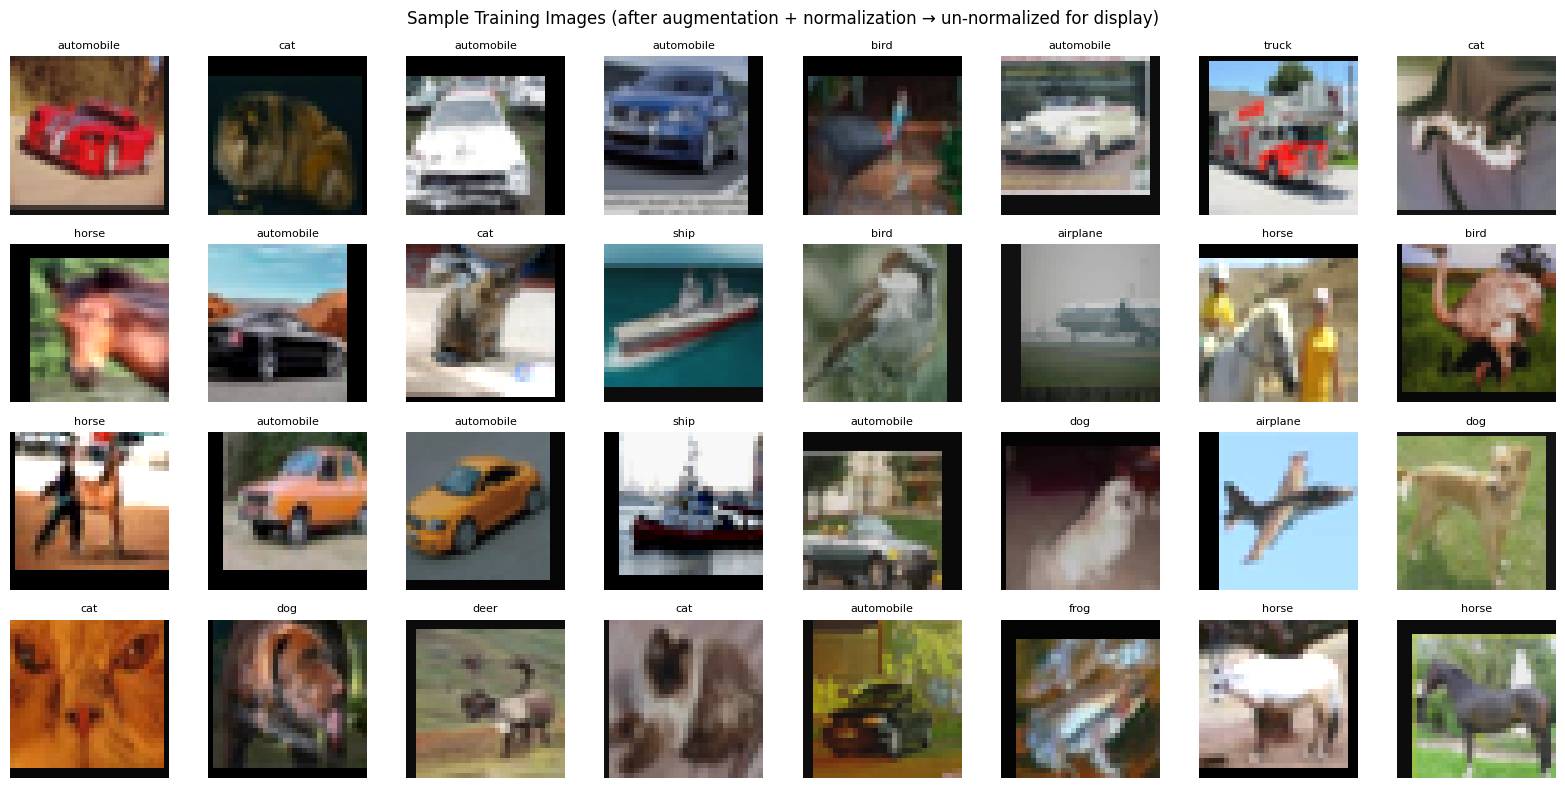

In [5]:
# ── Visualize a batch of training images ─────────────────────────────────────
# Note: images have been NORMALIZED, so we must un-normalize before display.

def unnormalize(tensor, mean, std):
    """Reverse the Normalize transform for display. tensor shape: (C,H,W)"""
    t = tensor.clone()
    for c in range(3):
        t[c] = t[c] * std[c] + mean[c]   # x_orig = x_norm * std + mean
    return t.clamp(0, 1)                  # clamp to valid display range

# Grab one batch
images, labels = next(iter(trainloader))
print(f'Batch shape: {images.shape}')   # (128, 3, 32, 32)
print(f'Labels shape: {labels.shape}')  # (128,)
print(f'Pixel value range after normalization: [{images.min():.2f}, {images.max():.2f}]')

# Display 32 images in a 4×8 grid
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('Sample Training Images (after augmentation + normalization → un-normalized for display)',
             fontsize=12)
for idx, ax in enumerate(axes.flat):
    img = unnormalize(images[idx], MEAN, STD)
    ax.imshow(img.permute(1, 2, 0).numpy())   # (C,H,W) → (H,W,C) for matplotlib
    ax.set_title(CLASSES[labels[idx]], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## 3. Data Augmentation — A Closer Look <a name='augmentation'></a>

Data augmentation artificially expands the effective size of the training set by applying **random, label-preserving transformations** to each image. The model never sees the exact same image twice, which discourages memorization and improves generalization.

**RandomHorizontalFlip:** A dog facing left and a dog facing right are still both dogs. The flip does not change the semantic class.

**RandomCrop with padding:** Shifts the image content slightly. The network learns that an airplane is still an airplane regardless of its position in the frame (translation invariance).

**ColorJitter:** Lighting conditions vary in the real world. Training on slightly different brightnesses and contrasts makes the model robust to camera exposure variations.

> **Key insight:** Augmentations are applied *randomly at training time*. The test set is *never augmented* — we want to evaluate on clean, representative images.

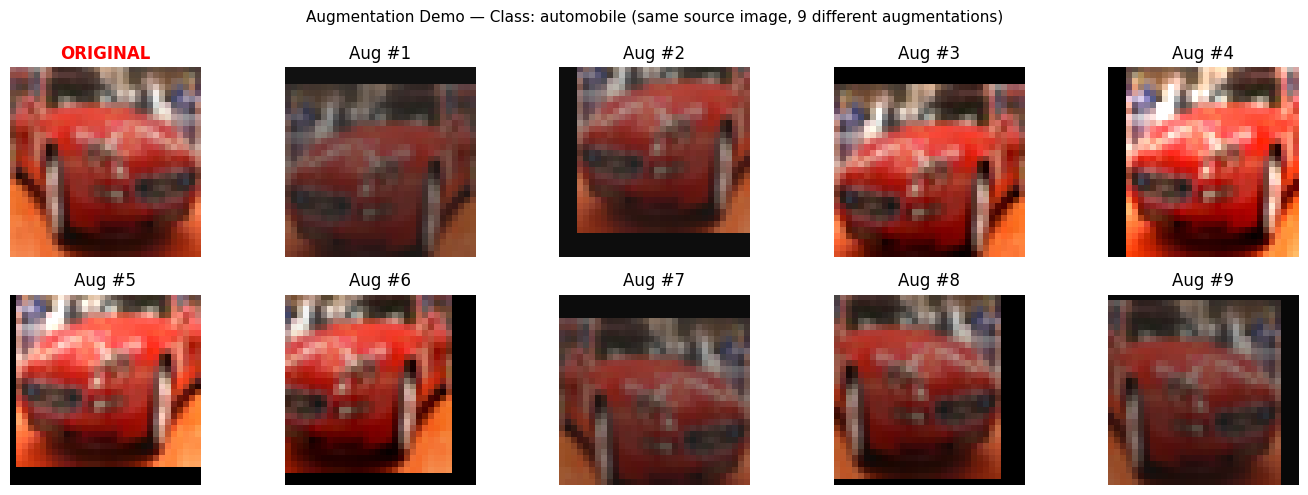

Notice: flips, slight crops/shifts, and brightness/contrast changes.
Every epoch, the model sees a different version of each training image.


In [6]:
# ── Show the effect of augmentation on a single image ────────────────────────
# We apply the training transform 8 times to the SAME source image
# to illustrate the diversity it produces.

# Get one raw PIL image from the dataset
raw_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                            download=False, transform=None)
raw_img, raw_label = raw_dataset[5]   # pick image index 5 (a frog)

# The augmentation-only transform (skip normalization for cleaner visualization)
aug_only = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
])

fig, axes = plt.subplots(2, 5, figsize=(14, 5))
fig.suptitle(f'Augmentation Demo — Class: {CLASSES[raw_label]} (same source image, 9 different augmentations)',
             fontsize=11)

# First cell: the original
axes[0, 0].imshow(raw_img)
axes[0, 0].set_title('ORIGINAL', fontweight='bold', color='red')
axes[0, 0].axis('off')

# Remaining 9 cells: random augmentations
all_axes = list(axes.flat)
for i in range(1, 10):
    aug_img = aug_only(raw_img)    # each call applies a NEW random transformation
    all_axes[i].imshow(aug_img)
    all_axes[i].set_title(f'Aug #{i}')
    all_axes[i].axis('off')

plt.tight_layout()
plt.show()
print('Notice: flips, slight crops/shifts, and brightness/contrast changes.')
print('Every epoch, the model sees a different version of each training image.')

---
## 4. Building a CNN from Scratch <a name='cnn'></a>

### The anatomy of a conv block
Almost every modern CNN is built from repeated **convolutional blocks**. A standard block has this structure:

```
Input feature map
    │
    ▼
[Conv2d]      ← learn spatial filters
    │
    ▼
[BatchNorm2d] ← normalize activations across the batch
    │
    ▼
[ReLU]        ← introduce nonlinearity (kill negative activations)
    │
    ▼
[MaxPool2d]   ← downsample spatially (stride 2 → half the width and height)
    │
    ▼
Output feature map (smaller, more channels)
```

### Conv2d parameters explained
```python
nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
#                  ↑             ↑               ↑           ↑
#    how many input      how many filters    filter size    'same' padding:
#    feature maps        to learn           (3×3 pixels)   preserves H and W
```

Each filter is a 3×3×32 tensor of learnable weights. The convolution slides this filter across the entire 32-channel input, computing a dot product at every position, and produces one output channel. With 64 filters, we produce 64 output channels.

### Batch Normalization
After convolution, activation values can be wildly different magnitudes across channels. BatchNorm normalizes each channel to zero mean and unit variance **across the batch dimension**, then applies learnable scale (γ) and shift (β) parameters. This:
- Stabilizes training (prevents vanishing/exploding gradients)
- Acts as a mild regularizer
- Allows higher learning rates

### Why Global Average Pooling instead of Flatten?
After the last conv block, we need to go from a 3D feature map (C×H×W) to a 1D vector for the classifier. Two approaches:
- **Flatten:** multiplies out all dimensions → huge FC layer, prone to overfitting
- **Global Average Pooling (GAP):** averages each channel over H×W → one number per channel → small, regularized representation

GAP is strongly preferred in modern architectures (ResNet, EfficientNet, etc.).

In [7]:
# ── Trace through dimensions manually ────────────────────────────────────────
# Before coding the full model, let's trace the spatial dimensions
# to understand exactly how data flows.

print('=== Manual dimension trace for a CIFAR-10 input (3×32×32) ===')
print()

# Useful formula:
#   output_size = floor((input_size + 2*padding - kernel_size) / stride) + 1

# Block 1: Conv(3→32, k=3, pad=1) → BN → ReLU → MaxPool(2,2)
H = 32
print(f'Input               : 3  × {H} × {H}')
H_after_conv = (H + 2*1 - 3) // 1 + 1   # stride=1 conv with padding=1 → same size
H_after_pool = H_after_conv // 2          # maxpool stride=2 → halves
print(f'After Block 1 (32ch): 32 × {H_after_pool} × {H_after_pool}  (pool halved H,W)')
H = H_after_pool

# Block 2: Conv(32→64, k=3, pad=1) → BN → ReLU → MaxPool(2,2)
H_after_pool = H // 2
print(f'After Block 2 (64ch): 64 × {H_after_pool} × {H_after_pool}')
H = H_after_pool

# Block 3: Conv(64→128, k=3, pad=1) → BN → ReLU → MaxPool(2,2)
H_after_pool = H // 2
print(f'After Block 3 (128ch): 128 × {H_after_pool} × {H_after_pool}')
H = H_after_pool

# Global Average Pooling: (128, 4, 4) → (128,)
print(f'After GAP           : 128  (one value per channel)')
print(f'After FC1 (128→256) : 256')
print(f'After FC2 (256→10)  : 10   (one logit per class)')
print()
print('That last 4×4 spatial map is why we stop at 3 pooling layers for 32×32 inputs.')
print('A 4th pool would give 2×2, and a 5th would give 1×1 — then GAP is pointless.')

=== Manual dimension trace for a CIFAR-10 input (3×32×32) ===

Input               : 3  × 32 × 32
After Block 1 (32ch): 32 × 16 × 16  (pool halved H,W)
After Block 2 (64ch): 64 × 8 × 8
After Block 3 (128ch): 128 × 4 × 4
After GAP           : 128  (one value per channel)
After FC1 (128→256) : 256
After FC2 (256→10)  : 10   (one logit per class)

That last 4×4 spatial map is why we stop at 3 pooling layers for 32×32 inputs.
A 4th pool would give 2×2, and a 5th would give 1×1 — then GAP is pointless.


In [8]:
# ── Define the CNN ────────────────────────────────────────────────────────────
class DemoCNN(nn.Module):
    """
    A compact CNN for CIFAR-10 classification.
    Architecture:
      Block1: Conv(3→32,  k=3) → BN → ReLU → MaxPool   → 32×16×16
      Block2: Conv(32→64, k=3) → BN → ReLU → MaxPool   → 64×8×8
      Block3: Conv(64→128,k=3) → BN → ReLU → MaxPool   → 128×4×4
      GAP                                               → 128
      Dropout(0.4)
      FC1: 128→256 → ReLU
      FC2: 256→10  → LogSoftmax
    """
    def __init__(self):
        super().__init__()

        # ── Convolutional blocks ──────────────────────────────────────────────
        # padding=1 on a 3×3 kernel is 'same' padding: output H,W = input H,W
        # The MaxPool(2,2) is what actually shrinks the spatial dimensions.
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 3  → 32 channels
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                           # 32×32 → 16×16
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 32 → 64 channels
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                           # 16×16 → 8×8
        )

        # Block 3 uses a 5×5 kernel to capture slightly larger spatial patterns.
        # padding=2 keeps the spatial size the same (same padding for k=5).
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=5, padding=2), # 64 → 128 channels
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                           # 8×8  → 4×4
        )

        # ── Classifier head ───────────────────────────────────────────────────
        # Global Average Pooling: AdaptiveAvgPool2d(1) collapses H×W to 1×1
        # regardless of input size (great for transfer learning later).
        self.gap = nn.AdaptiveAvgPool2d(1)   # 128×4×4 → 128×1×1

        self.dropout = nn.Dropout(p=0.4)

        self.fc1 = nn.Linear(128, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        # x shape on entry: (batch_size, 3, 32, 32)
        x = self.block1(x)           # → (B, 32, 16, 16)
        x = self.block2(x)           # → (B, 64,  8,  8)
        x = self.block3(x)           # → (B, 128,  4,  4)
        x = self.gap(x)              # → (B, 128,  1,  1)
        x = x.view(x.size(0), -1)   # → (B, 128)          flatten
        x = self.dropout(x)
        x = F.relu(self.fc1(x))      # → (B, 256)
        x = self.fc2(x)              # → (B, 10)  raw logits
        return F.log_softmax(x, dim=1)  # → (B, 10) log-probabilities

# ── Instantiate and send to GPU ───────────────────────────────────────────────
model = DemoCNN().to(device)

# ── Count parameters ─────────────────────────────────────────────────────────
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print()
print(model)

Total parameters    : 260,362
Trainable parameters: 260,362

DemoCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (gap): Adaptive

In [9]:
# ── Verify the forward pass dimensions with a dummy batch ────────────────────
# ALWAYS do this before training to catch shape mismatches early.
dummy_input = torch.randn(4, 3, 32, 32).to(device)  # batch of 4 random images
with torch.no_grad():
    dummy_output = model(dummy_input)

print(f'Input shape  : {dummy_input.shape}')
print(f'Output shape : {dummy_output.shape}')  # should be (4, 10)
print(f'Output (log-softmax): should be negative values summing to 0 per sample')
print(f'exp(output).sum(dim=1) should be ~1.0:', torch.exp(dummy_output).sum(dim=1))

Input shape  : torch.Size([4, 3, 32, 32])
Output shape : torch.Size([4, 10])
Output (log-softmax): should be negative values summing to 0 per sample
exp(output).sum(dim=1) should be ~1.0: tensor([1.0000, 1.0000, 1.0000, 1.0000], device='cuda:0')


---
## 5. The Training Loop <a name='training'></a>

### The optimization cycle
Training a neural network repeats one cycle for each mini-batch:

```
1. FORWARD PASS:   compute predictions    loss = criterion(model(x), y)
2. ZERO GRADIENTS: clear old gradients    optimizer.zero_grad()
3. BACKWARD PASS:  compute gradients      loss.backward()
4. UPDATE WEIGHTS: gradient descent step  optimizer.step()
```

**Why `zero_grad()` before `backward()`?**  
PyTorch *accumulates* gradients by default. If we don't zero them, the gradient from batch 2 is added on top of the gradient from batch 1, giving a wrong (accumulated) value. We zero them at the start of every batch.

### Loss function: NLLLoss vs CrossEntropyLoss
- Our model outputs `log_softmax`, so we use `NLLLoss` (Negative Log Likelihood).
- If the model output raw logits, we'd use `CrossEntropyLoss` (which fuses softmax + NLL).
- Mathematically equivalent, just different places to put the softmax.

### Learning rate scheduler
A fixed learning rate is rarely optimal. Early in training, a large LR makes fast progress. Later, when near a good minimum, a large LR causes oscillation. **CosineAnnealingLR** smoothly reduces the LR from its initial value to near zero, following a cosine curve. This reliably improves final accuracy by ~1–2% compared to a fixed LR.

/tmp/ipython-input-509/501424803.py:12: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  demo_scheduler.step()


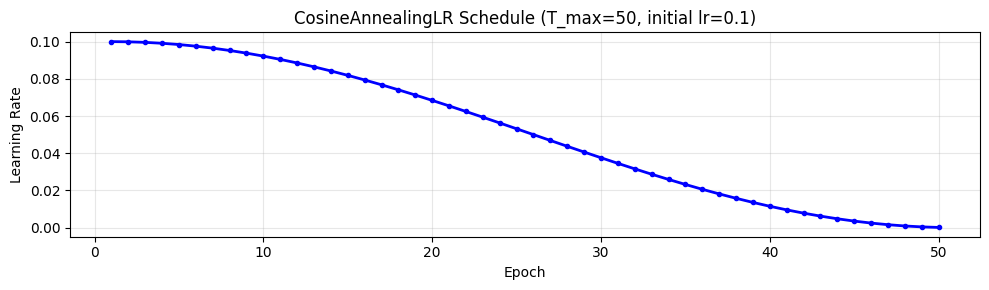

The LR starts at 0.1 and smoothly decays to ~0 by epoch 50.
This lets the optimizer take large steps early and small, precise steps late.


In [10]:
# ── Visualize the CosineAnnealingLR schedule ─────────────────────────────────
# This helps students understand WHAT the scheduler is doing before
# they use it in their training loop.

demo_model = DemoCNN()  # fresh model for demo only (no GPU needed)
demo_optim = optim.SGD(demo_model.parameters(), lr=0.1, momentum=0.9)
demo_scheduler = optim.lr_scheduler.CosineAnnealingLR(demo_optim, T_max=50)

lrs = []
for epoch in range(50):
    lrs.append(demo_optim.param_groups[0]['lr'])
    demo_scheduler.step()

plt.figure(figsize=(10, 3))
plt.plot(range(1, 51), lrs, 'b-o', markersize=3, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('CosineAnnealingLR Schedule (T_max=50, initial lr=0.1)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('The LR starts at 0.1 and smoothly decays to ~0 by epoch 50.')
print('This lets the optimizer take large steps early and small, precise steps late.')

In [11]:
# ── Full training loop ────────────────────────────────────────────────────────
# We train for only 15 epochs here to keep class time short.
# In HW4 you will train for 50 epochs to reach >= 80% accuracy.

model = DemoCNN().to(device)  # fresh model

criterion = nn.NLLLoss()   # pairs with log_softmax output
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

NUM_EPOCHS = 15

# Storage for plotting
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
best_test_acc = 0.0

def evaluate(loader, model, criterion, device):
    """Compute loss and accuracy on a DataLoader. Does NOT update weights."""
    model.eval()   # <-- CRITICAL: disables Dropout and sets BN to eval mode
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():   # <-- CRITICAL: disables gradient computation (saves memory)
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)  # accumulate total loss
            preds = outputs.argmax(dim=1)               # index of highest log-prob
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, 100.0 * correct / total


print(f'Training for {NUM_EPOCHS} epochs on {device}...')
print(f'{"Epoch":>6}  {"Train Loss":>10}  {"Train Acc":>10}  {"Test Loss":>10}  {"Test Acc":>10}  {"LR":>8}')
print('-' * 65)

t0 = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    # ── Training phase ────────────────────────────────────────────────────────
    model.train()   # <-- enables Dropout and BN training mode
    running_loss, running_correct, running_total = 0.0, 0, 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)  # move to GPU

        optimizer.zero_grad()            # 1. clear old gradients
        outputs = model(images)          # 2. forward pass
        loss = criterion(outputs, labels)# 3. compute loss
        loss.backward()                  # 4. backprop: compute all ∂loss/∂weight
        optimizer.step()                 # 5. gradient descent step

        running_loss    += loss.item() * images.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        running_total   += labels.size(0)

    train_loss = running_loss / running_total
    train_acc  = 100.0 * running_correct / running_total

    # ── Evaluation phase ──────────────────────────────────────────────────────
    test_loss, test_acc = evaluate(testloader, model, criterion, device)

    scheduler.step()   # update LR AFTER the epoch

    # Save best checkpoint
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), 'best_model.pth')  # save weights only

    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f'{epoch:>6}  {train_loss:>10.4f}  {train_acc:>9.2f}%  '
          f'{test_loss:>10.4f}  {test_acc:>9.2f}%  {current_lr:>8.5f}')

elapsed = time.time() - t0
print('-' * 65)
print(f'Training complete in {elapsed:.0f}s  |  Best test accuracy: {best_test_acc:.2f}%')

Training for 15 epochs on cuda...
 Epoch  Train Loss   Train Acc   Test Loss    Test Acc        LR
-----------------------------------------------------------------
     1      1.6860      36.13%      1.5561      43.48%   0.09891
     2      1.3166      52.23%      1.3704      51.80%   0.09568
     3      1.1377      58.80%      1.2725      55.96%   0.09045
     4      1.0482      62.31%      1.1220      59.88%   0.08346
     5      0.9698      65.62%      0.9655      64.99%   0.07500
     6      0.9161      67.78%      0.7848      72.31%   0.06545
     7      0.8604      69.78%      0.8181      70.59%   0.05523
     8      0.8172      71.38%      0.7331      73.88%   0.04477
     9      0.7799      72.64%      0.7344      74.23%   0.03455
    10      0.7455      74.16%      0.7136      74.22%   0.02500
    11      0.7118      75.10%      0.6439      77.71%   0.01654
    12      0.6812      76.20%      0.6388      77.68%   0.00955
    13      0.6589      77.07%      0.5773      79.69% 

---
## 6. Evaluating & Plotting Results <a name='evaluation'></a>

After training, we must look beyond a single accuracy number:

- **Loss curves** tell us whether training is still improving and whether the model is overfitting.
- **The generalization gap** (train acc − test acc) reveals overfitting. A large gap means the model has memorized the training set.
- **The confusion matrix** reveals *which* classes are confused with each other — critical for understanding failure modes.

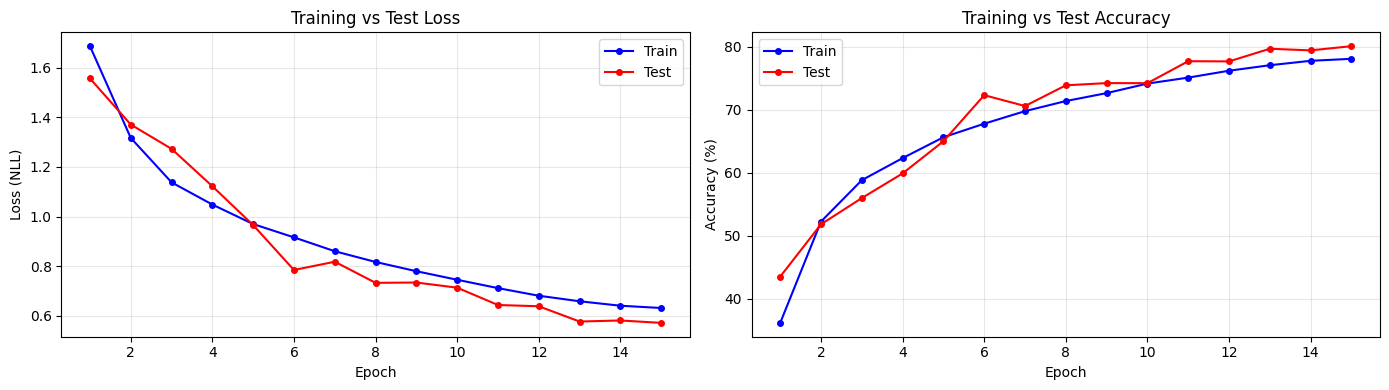

Final train accuracy : 78.09%
Final test accuracy  : 80.10%
Generalization gap   : -2.01%
→ Small gap: model is generalizing well.


In [12]:
# ── Loss and accuracy curves ──────────────────────────────────────────────────
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Loss
ax1.plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Train')
ax1.plot(epochs, history['test_loss'],  'r-o', markersize=4, label='Test')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (NLL)')
ax1.set_title('Training vs Test Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs, history['train_acc'], 'b-o', markersize=4, label='Train')
ax2.plot(epochs, history['test_acc'],  'r-o', markersize=4, label='Test')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training vs Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

gap = history['train_acc'][-1] - history['test_acc'][-1]
print(f'Final train accuracy : {history["train_acc"][-1]:.2f}%')
print(f'Final test accuracy  : {history["test_acc"][-1]:.2f}%')
print(f'Generalization gap   : {gap:.2f}%')
if gap > 10:
    print('→ Large gap: model may be overfitting. Consider more dropout or augmentation.')
else:
    print('→ Small gap: model is generalizing well.')

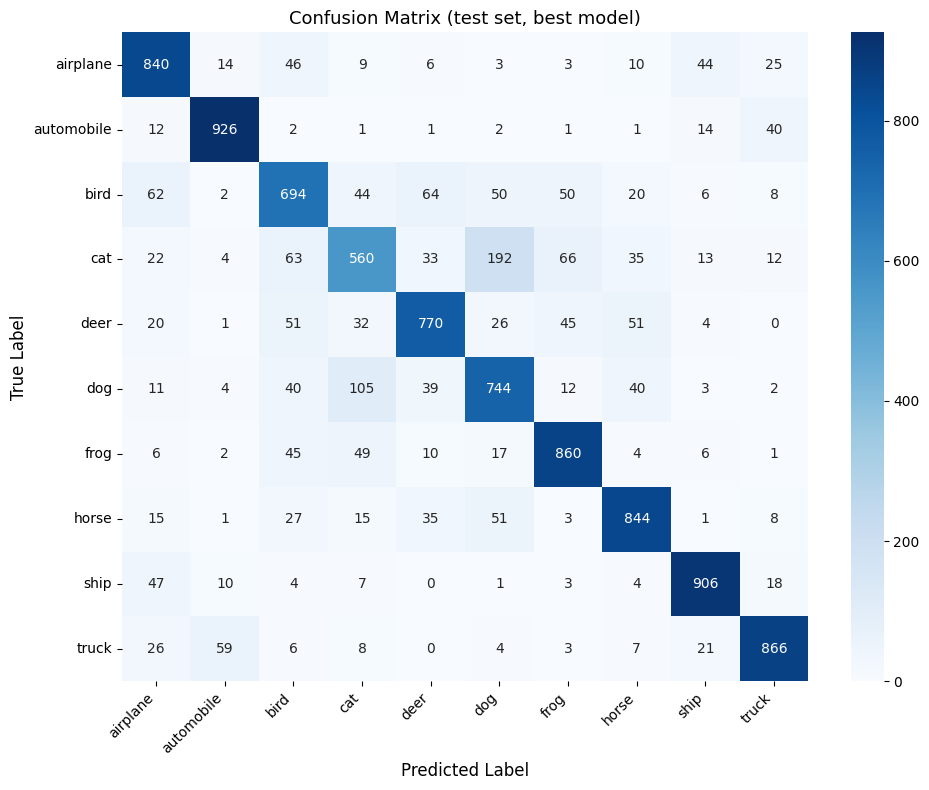


Per-class report:
              precision    recall  f1-score   support

    airplane       0.79      0.84      0.82      1000
  automobile       0.91      0.93      0.92      1000
        bird       0.71      0.69      0.70      1000
         cat       0.67      0.56      0.61      1000
        deer       0.80      0.77      0.79      1000
         dog       0.68      0.74      0.71      1000
        frog       0.82      0.86      0.84      1000
       horse       0.83      0.84      0.84      1000
        ship       0.89      0.91      0.90      1000
       truck       0.88      0.87      0.87      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



In [13]:
# ── Confusion matrix ─────────────────────────────────────────────────────────
# Load the best checkpoint before evaluation
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix (test set, best model)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print()
print('Per-class report:')
print(classification_report(all_labels, all_preds, target_names=CLASSES))

### Reading the confusion matrix

- **Diagonal entries** = correct predictions. We want these to be large.
- **Off-diagonal entries** = errors. Entry (i, j) = number of class-i images predicted as class j.
- Look for symmetric off-diagonal pairs (e.g., cat/dog or automobile/truck). These represent semantically similar classes.

Common confusions in CIFAR-10 at this accuracy level:
- **cat ↔ dog** (both are small furry animals with similar textures)
- **automobile ↔ truck** (similar boxy shapes; hard to tell apart at 32×32)
- **deer ↔ horse** (similar body shapes and backgrounds)

---
## 7. Filter & Feature Map Visualization <a name='visualization'></a>

### Why visualize?
Visualizing what a CNN has learned is essential for:
- **Debugging** — if filters look like random noise after training, something went wrong
- **Understanding** — seeing that early layers learn edges/textures and later layers learn object parts
- **Explainability** — answering "what is the model actually looking at?"

### PyTorch hooks
A **forward hook** is a callback function that PyTorch calls automatically after a specified layer runs during a forward pass. This lets us intercept and save intermediate tensors without modifying the model's `forward()` method.

First-layer filter tensor shape: torch.Size([32, 3, 3, 3])
  (num_filters, in_channels, kernel_H, kernel_W) = (32, 3, 3, 3)


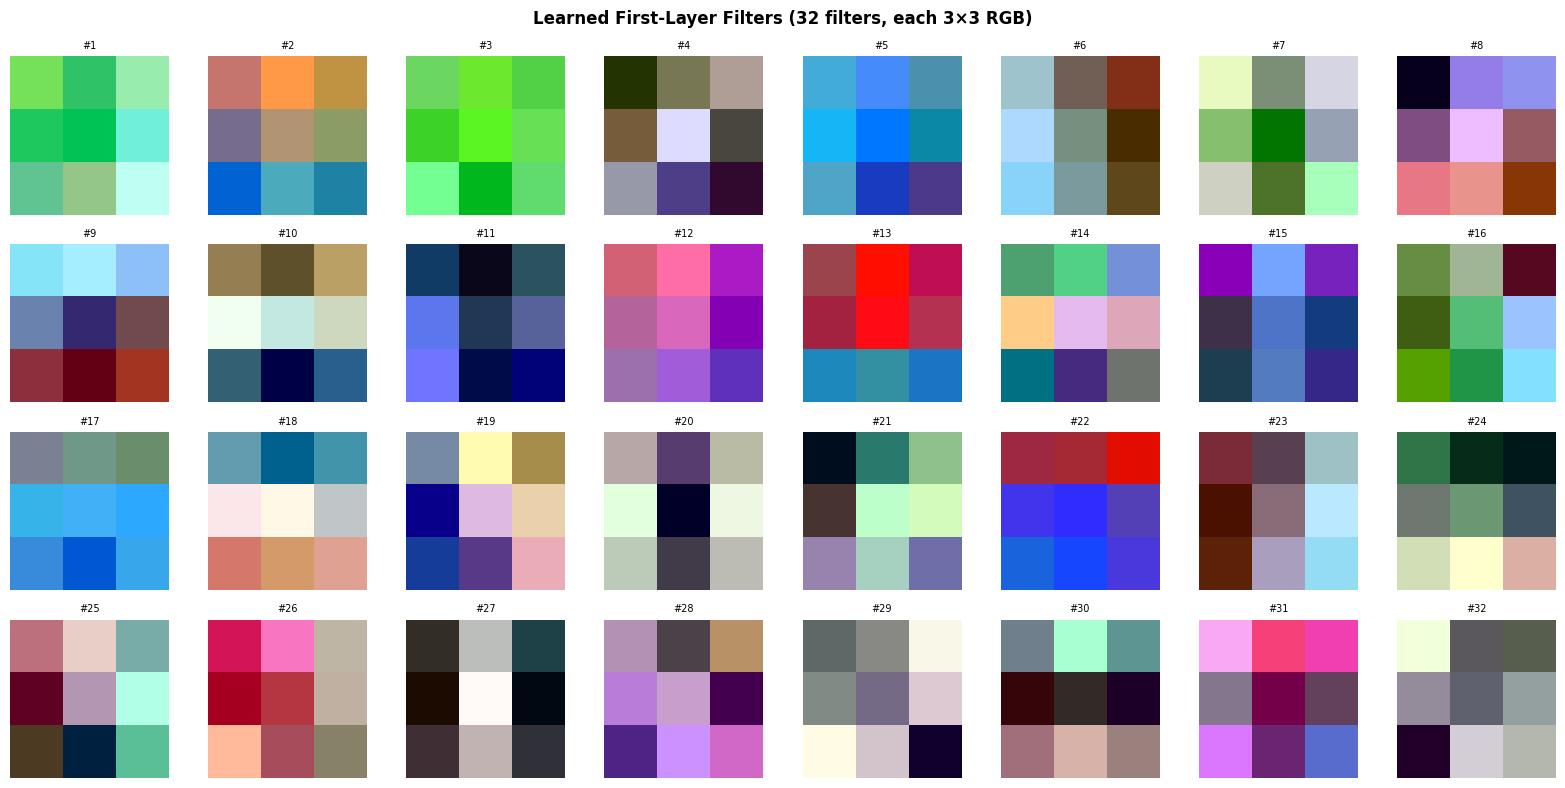


What to look for:
  - Edge detectors: bright on one side, dark on the other
  - Color filters: uniform hue (detect presence of a color)
  - Noise-like filters: indicates this filter may be underused


In [14]:
# ── First-layer filter visualization ─────────────────────────────────────────
# The first Conv2d layer has 32 filters, each of shape (3, 3, 3) = (C_in, H, W).
# Since C_in = 3 (RGB), each filter IS an RGB image and can be displayed directly.

# Extract the weight tensor from the first Conv2d layer
# model.block1[0] is the nn.Conv2d layer (index 0 in the Sequential)
filters = model.block1[0].weight.data.cpu()  # shape: (32, 3, 3, 3)
print(f'First-layer filter tensor shape: {filters.shape}')
print('  (num_filters, in_channels, kernel_H, kernel_W) = (32, 3, 3, 3)')

# Normalize each filter to [0, 1] for visualization
def normalize_filter(f):
    f_min, f_max = f.min(), f.max()
    return (f - f_min) / (f_max - f_min + 1e-8)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('Learned First-Layer Filters (32 filters, each 3×3 RGB)',
             fontsize=12, fontweight='bold')
for i, ax in enumerate(axes.flat):
    filt = normalize_filter(filters[i])   # (3, 3, 3)
    ax.imshow(filt.permute(1, 2, 0))      # (H, W, C)
    ax.set_title(f'#{i+1}', fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()

print()
print('What to look for:')
print('  - Edge detectors: bright on one side, dark on the other')
print('  - Color filters: uniform hue (detect presence of a color)')
print('  - Noise-like filters: indicates this filter may be underused')

In [15]:
# ── Feature map visualization with hooks ─────────────────────────────────────
# Strategy: register a forward hook on each block to capture its output tensor.

activations = {}  # dictionary to store captured outputs
hook_handles = []  # keep handles so we can remove hooks later

def make_hook(name):
    """
    Returns a hook function that saves the output of a layer
    under `name` in the `activations` dict.
    The hook signature is: hook(module, input, output)
    """
    def hook(module, input, output):
        activations[name] = output.detach()  # .detach() prevents memory leak
    return hook

# Register hooks on the output of each block
hook_handles.append(model.block1.register_forward_hook(make_hook('block1')))
hook_handles.append(model.block2.register_forward_hook(make_hook('block2')))
hook_handles.append(model.block3.register_forward_hook(make_hook('block3')))

# Run one image through the network
model.eval()
sample_img, sample_label = testset[0]  # grab the first test image
with torch.no_grad():
    # Add batch dimension: (3,32,32) → (1,3,32,32), then move to GPU
    model(sample_img.unsqueeze(0).to(device))

# Remove hooks (good practice — always clean up to avoid side effects)
for h in hook_handles:
    h.remove()

print('Captured activation shapes:')
for name, act in activations.items():
    print(f'  {name}: {act.shape}  (batch=1, channels, H, W)')

Captured activation shapes:
  block1: torch.Size([1, 32, 16, 16])  (batch=1, channels, H, W)
  block2: torch.Size([1, 64, 8, 8])  (batch=1, channels, H, W)
  block3: torch.Size([1, 128, 4, 4])  (batch=1, channels, H, W)


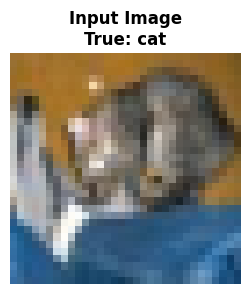

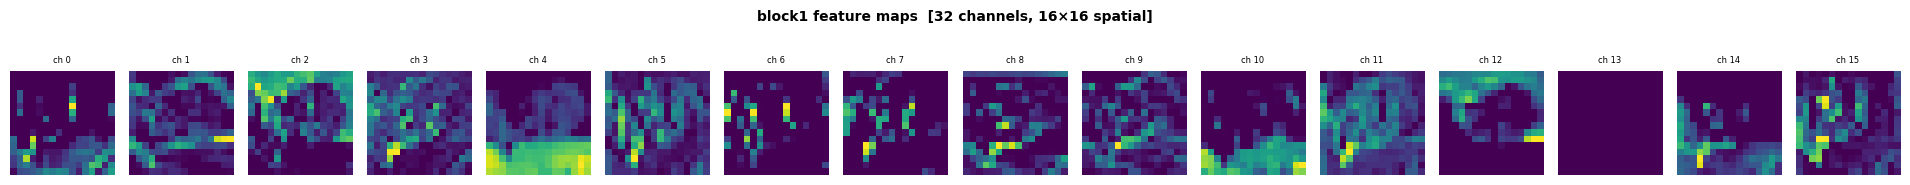

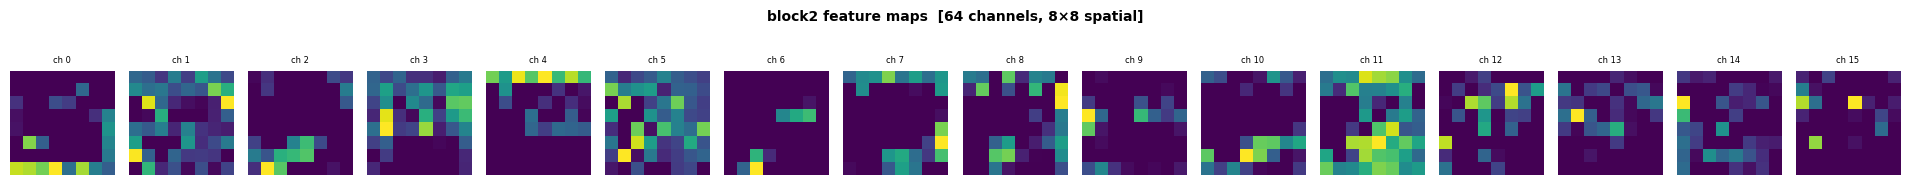

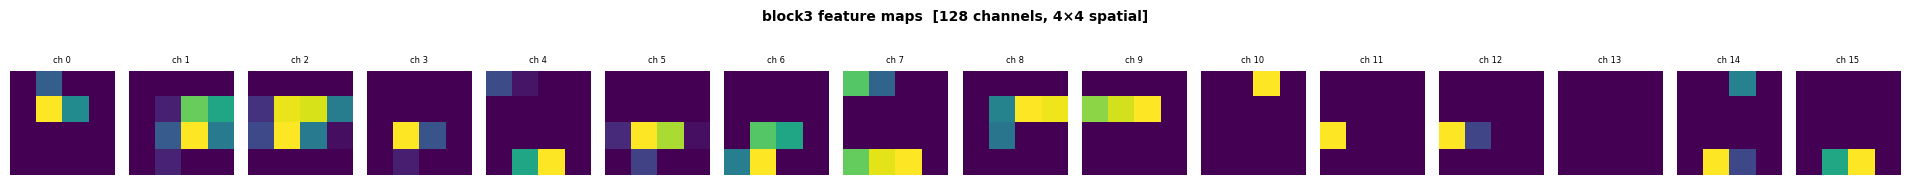


Observations:
  Block 1 (16×16): Feature maps still look like the input — edge-like patterns, large spatial detail.
  Block 2  (8×8) : More abstract; specific textures or regions start to dominate.
  Block 3  (4×4) : Highly abstract, small spatial maps. Each channel represents a high-level concept.


In [16]:
# ── Display feature maps for all three blocks ─────────────────────────────────

def plot_feature_maps(act_dict, source_img, true_label, n_channels=16):
    """Plot the first n_channels feature maps from each conv block."""

    # Show the source image
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))
    ax.imshow(unnormalize(source_img, MEAN, STD).permute(1,2,0).numpy())
    ax.set_title(f'Input Image\nTrue: {CLASSES[true_label]}', fontweight='bold')
    ax.axis('off')
    plt.show()

    for block_name, feat in act_dict.items():
        # feat shape: (1, C, H, W)  -- we take batch index 0
        feat = feat[0].cpu()   # shape: (C, H, W)
        C, H, W = feat.shape

        cols = min(n_channels, C)
        fig, axes = plt.subplots(1, cols, figsize=(cols * 1.2, 1.8))
        fig.suptitle(f'{block_name} feature maps  [{C} channels, {H}×{W} spatial]',
                     fontsize=10, fontweight='bold', y=1.05)

        for i, ax in enumerate(axes):
            ch = feat[i].numpy()
            # Normalize each channel independently to [0,1]
            ch_norm = (ch - ch.min()) / (ch.max() - ch.min() + 1e-8)
            ax.imshow(ch_norm, cmap='viridis')
            ax.set_title(f'ch {i}', fontsize=6)
            ax.axis('off')

        plt.tight_layout()
        plt.show()

plot_feature_maps(activations, sample_img, sample_label, n_channels=16)

print('\nObservations:')
print('  Block 1 (16×16): Feature maps still look like the input — edge-like patterns, large spatial detail.')
print('  Block 2  (8×8) : More abstract; specific textures or regions start to dominate.')
print('  Block 3  (4×4) : Highly abstract, small spatial maps. Each channel represents a high-level concept.')

---
## 8. Grad-CAM — Where is the Model Looking? <a name='gradcam'></a>

**Gradient-weighted Class Activation Mapping (Grad-CAM)** answers the question: *which spatial regions of an input image are most important for the predicted class?*

### Algorithm (intuition first)
1. Run a forward pass and keep the last convolutional feature map A (shape: C×H×W).
2. Compute the gradient of the score for the predicted class with respect to A. This tells us: if we change channel k of A by a tiny amount at position (i,j), how much does the class score change?
3. Global-average-pool the gradients over H×W to get one importance weight αₖ per channel. A large αₖ means channel k strongly influences the prediction.
4. The Grad-CAM heatmap = ReLU(∑ₖ αₖ · Aₖ). The ReLU discards negative contributions (regions that hurt the score).
5. Upsample the heatmap to the input image size and overlay it.

### Why ReLU?
We only care about pixels that *positively* contribute to the predicted class. Negative activations (pixels that push toward *other* classes) are not what we want to highlight.

In [17]:
# ── Grad-CAM implementation ───────────────────────────────────────────────────

class GradCAM:
    """
    Simple Grad-CAM implementation using forward and backward hooks.
    Works with any CNN that has a clearly identified 'target layer'.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.feature_map = None   # captured in forward hook
        self.gradients   = None   # captured in backward hook

        # Forward hook: save the output of the target layer
        target_layer.register_forward_hook(self._save_features)
        # Backward hook: save the gradient flowing INTO the target layer
        target_layer.register_full_backward_hook(self._save_gradients)

    def _save_features(self, module, input, output):
        self.feature_map = output  # (1, C, H, W)

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]  # (1, C, H, W)

    def __call__(self, x, class_idx=None):
        """
        x: input tensor (1, 3, H, W) on the same device as the model
        class_idx: which class to compute Grad-CAM for;
                   if None, uses the predicted class
        Returns: heatmap (H, W) as a numpy array in [0, 1]
        """
        self.model.eval()
        self.model.zero_grad()

        # Forward pass — we need gradients, so NO torch.no_grad()
        output = self.model(x)                    # (1, num_classes)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        # Backward pass: compute d(score_c) / d(feature_map)
        # We set all class scores to zero except the target class
        score = output[0, class_idx]              # scalar
        score.backward()                          # fills self.gradients

        # Step 3: global average pool the gradients → one weight per channel
        # self.gradients shape: (1, C, H, W)
        alpha = self.gradients[0].mean(dim=[1, 2])  # shape: (C,)

        # Step 4: weighted sum of feature maps + ReLU
        # self.feature_map shape: (1, C, H, W)
        cam = (alpha[:, None, None] * self.feature_map[0]).sum(dim=0)  # (H, W)
        cam = F.relu(cam)                                              # discard negatives

        # Step 5: normalize to [0, 1]
        cam = cam.detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


# Instantiate Grad-CAM targeting the last conv block
gradcam = GradCAM(model, model.block3)
print('GradCAM initialized, targeting block3 (last conv block).')

GradCAM initialized, targeting block3 (last conv block).


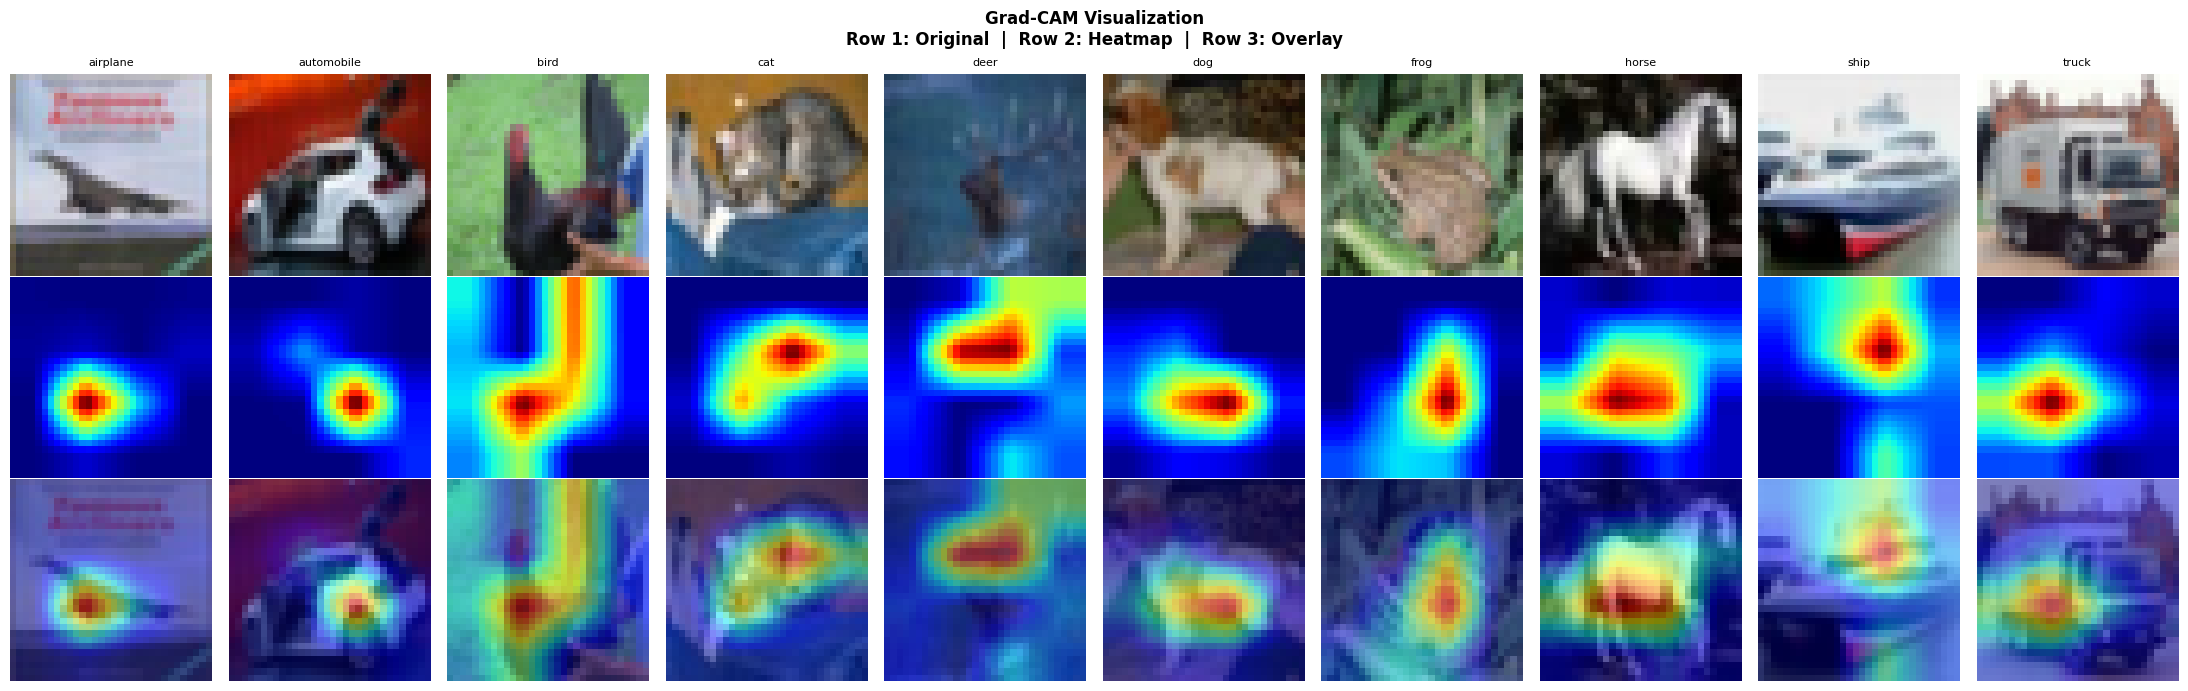

Hot (red/yellow) regions = high importance for the predicted class.
Cool (blue) regions = low importance.


In [18]:
import torch # Added import torch
import torch.nn.functional as F_func  # for interpolate

# Collect one correctly classified example per class
class_examples = {}   # class_idx → (image_tensor, label)
with torch.no_grad():
    for img, lbl in testset:
        if lbl not in class_examples:
            inp = img.unsqueeze(0).to(device)
            pred = model(inp).argmax(dim=1).item()
            if pred == lbl:  # only use correctly classified images
                class_examples[lbl] = img
        if len(class_examples) == 10:
            break

fig, axes = plt.subplots(3, 10, figsize=(22, 7))
fig.suptitle('Grad-CAM Visualization\nRow 1: Original  |  Row 2: Heatmap  |  Row 3: Overlay',
             fontsize=12, fontweight='bold')

for col_idx, (class_idx, img_tensor) in enumerate(sorted(class_examples.items())):
    inp = img_tensor.unsqueeze(0).to(device)

    # Compute Grad-CAM heatmap (4×4 from block3)
    cam, pred_idx = gradcam(inp, class_idx=class_idx)  # (4, 4)

    # Upsample heatmap to 32×32
    cam_tensor = torch.from_numpy(cam).unsqueeze(0).unsqueeze(0).float()  # (1,1,4,4)
    cam_up = F_func.interpolate(cam_tensor, size=(32, 32), mode='bilinear',
                                align_corners=False)[0, 0].numpy()  # (32, 32)

    # Original image (un-normalized)
    orig = unnormalize(img_tensor, MEAN, STD).permute(1,2,0).numpy()

    # Overlay: blend original image with red heatmap
    heatmap_colored = plt.cm.jet(cam_up)[..., :3]       # (32, 32, 3) RGB
    overlay = 0.5 * orig + 0.5 * heatmap_colored
    overlay = overlay.clip(0, 1)

    axes[0, col_idx].imshow(orig)
    axes[0, col_idx].set_title(CLASSES[class_idx], fontsize=8)
    axes[0, col_idx].axis('off')

    axes[1, col_idx].imshow(cam_up, cmap='jet')
    axes[1, col_idx].axis('off')

    axes[2, col_idx].imshow(overlay)
    axes[2, col_idx].axis('off')

plt.tight_layout()
plt.show()
print('Hot (red/yellow) regions = high importance for the predicted class.')
print('Cool (blue) regions = low importance.')

---
## 9. Transfer Learning with ResNet-18 <a name='transfer'></a>

### What is transfer learning?
Training a deep CNN from scratch on a small dataset requires large amounts of data and compute. **Transfer learning** sidesteps this by starting from a model already trained on a massive dataset (ImageNet, 1.2M images, 1000 classes) and adapting it to our task.

The key insight: **the early convolutional layers learn general features** (edges, textures, shapes) that are useful across virtually all visual tasks. Only the final classification head is specific to the original dataset's 1000 classes.

### Two modes of transfer learning

| Mode | Which layers update? | When to use |
|---|---|---|
| **Feature extraction** | Only new FC head | Very small dataset (<1K images/class) |
| **Fine-tuning** | All layers (with differential LRs) | Moderate dataset; best accuracy |

### ResNet-18 architecture overview
ResNet-18 consists of:
- `conv1`: 7×7 convolution
- `bn1 + relu + maxpool`
- `layer1..4`: residual blocks (skip connections add input to output)
- `avgpool`: global average pooling → 512-dim vector
- `fc`: 512 → 1000 (ImageNet classes)

We replace the `fc` layer with our own `Linear(512, 10)` for CIFAR-10.

In [19]:
# ── Transfer Learning: Feature Extraction Mode ────────────────────────────────
# Step 1: Load pretrained ResNet-18
resnet = models.resnet18(pretrained=True)

# Step 2: Freeze ALL parameters
for param in resnet.parameters():
    param.requires_grad = False   # frozen → will NOT be updated during training

# Step 3: Replace the classification head with one for 10 classes
# resnet.fc is the final fully-connected layer: Linear(512 → 1000)
# We replace it with Linear(512 → 10). The new layer's parameters
# default to requires_grad=True, so only the head trains.
in_features = resnet.fc.in_features   # 512 for ResNet-18
resnet.fc = nn.Linear(in_features, 10)

resnet = resnet.to(device)

# Verify: only the new fc layer should have requires_grad=True
total_params     = sum(p.numel() for p in resnet.parameters())
trainable_params = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}  (should be only the new FC head)')
print(f'Frozen params    : {total_params - trainable_params:,}')

# For ResNet-18, FC is Linear(512, 10): 512*10 + 10 = 5,130 trainable params
expected = in_features * 10 + 10
print(f'Expected trainable: {expected:,} = {in_features}×10 + 10 (weights + biases)')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 134MB/s]


Total params     : 11,181,642
Trainable params : 5,130  (should be only the new FC head)
Frozen params    : 11,176,512
Expected trainable: 5,130 = 512×10 + 10 (weights + biases)


In [20]:
# ── Prepare ResNet-specific data loaders ─────────────────────────────────────
# ResNet was trained on ImageNet (224×224). We must resize CIFAR-10 (32×32)
# to 224×224 AND use ImageNet normalization statistics.

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

rn_train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
rn_test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

rn_trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                           download=False, transform=rn_train_transform)
rn_testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=False, transform=rn_test_transform)

# Use smaller batch size: 224×224 images are ~49× larger than 32×32
rn_trainloader = torch.utils.data.DataLoader(rn_trainset, batch_size=64,
                                             shuffle=True, num_workers=2)
rn_testloader  = torch.utils.data.DataLoader(rn_testset,  batch_size=64,
                                             shuffle=False, num_workers=2)
print('ResNet data loaders ready. Batch size=64, images resized to 224×224.')

ResNet data loaders ready. Batch size=64, images resized to 224×224.


In [21]:
# ── Train the FC head only (Feature Extraction) ───────────────────────────────
# Since most layers are frozen, this trains VERY fast.

# Only pass parameters with requires_grad=True to the optimizer!
# Passing frozen params is harmless but wastes memory and adds confusion.
rn_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, resnet.parameters()),
    lr=1e-3
)
rn_criterion = nn.CrossEntropyLoss()  # resnet outputs raw logits (no log_softmax)
rn_scheduler = optim.lr_scheduler.StepLR(rn_optimizer, step_size=5, gamma=0.5)

RN_EPOCHS = 5  # feature extraction converges quickly
print(f'Training ResNet-18 FC head only for {RN_EPOCHS} epochs...')
print(f'{"Epoch":>6}  {"Test Acc":>10}')
print('-' * 25)

for epoch in range(1, RN_EPOCHS + 1):
    resnet.train()
    for images, labels in rn_trainloader:
        images, labels = images.to(device), labels.to(device)
        rn_optimizer.zero_grad()
        outputs = resnet(images)
        loss = rn_criterion(outputs, labels)
        loss.backward()
        rn_optimizer.step()
    rn_scheduler.step()
    _, test_acc = evaluate(rn_testloader, resnet, rn_criterion, device)
    print(f'{epoch:>6}  {test_acc:>9.2f}%')

print()
print('Note: Even with only 5,130 trainable parameters, we get strong accuracy')
print('because the frozen backbone already contains powerful visual features.')

Training ResNet-18 FC head only for 5 epochs...
 Epoch    Test Acc
-------------------------
     1      77.63%
     2      80.15%
     3      79.88%
     4      80.07%
     5      79.75%

Note: Even with only 5,130 trainable parameters, we get strong accuracy
because the frozen backbone already contains powerful visual features.


In [22]:
# ── Fine-tuning: differential learning rates ──────────────────────────────────
# Reload pretrained ResNet and replace FC
resnet_ft = models.resnet18(pretrained=True)
resnet_ft.fc = nn.Linear(resnet_ft.fc.in_features, 10)
resnet_ft = resnet_ft.to(device)

# ALL layers now have requires_grad=True (default for pretrained models)
# We use DIFFERENT learning rates for backbone vs. head:
#   - Backbone: small LR (1e-4) — we don't want to destroy pretrained features
#   - Head:     large LR (1e-3) — this layer is random, needs to learn quickly

backbone_params = [p for name, p in resnet_ft.named_parameters() if 'fc' not in name]
head_params     = list(resnet_ft.fc.parameters())

ft_optimizer = optim.Adam([
    {'params': backbone_params, 'lr': 1e-4},   # slow LR for backbone
    {'params': head_params,     'lr': 1e-3},   # fast LR for head
])
ft_criterion = nn.CrossEntropyLoss()

FT_EPOCHS = 5   # fine-tuning also converges fast with pretrained init
print(f'Fine-tuning ALL ResNet-18 layers (differential LR) for {FT_EPOCHS} epochs...')
print(f'  backbone lr = 1e-4,  head lr = 1e-3')
print(f'{"Epoch":>6}  {"Test Acc":>10}')
print('-' * 25)

for epoch in range(1, FT_EPOCHS + 1):
    resnet_ft.train()
    for images, labels in rn_trainloader:
        images, labels = images.to(device), labels.to(device)
        ft_optimizer.zero_grad()
        outputs = resnet_ft(images)
        loss = ft_criterion(outputs, labels)
        loss.backward()
        ft_optimizer.step()
    _, test_acc = evaluate(rn_testloader, resnet_ft, ft_criterion, device)
    print(f'{epoch:>6}  {test_acc:>9.2f}%')

print()
print('Fine-tuning outperforms feature extraction by allowing the backbone')
print('to slightly adapt its features to CIFAR-10 textures.')

Fine-tuning ALL ResNet-18 layers (differential LR) for 5 epochs...
  backbone lr = 1e-4,  head lr = 1e-3
 Epoch    Test Acc
-------------------------
     1      93.23%
     2      93.12%
     3      94.07%
     4      93.49%
     5      94.08%

Fine-tuning outperforms feature extraction by allowing the backbone
to slightly adapt its features to CIFAR-10 textures.


---
## 10. CNN as a Feature Extractor for kNN <a name='features'></a>

A trained CNN is not just a classifier — it is also a powerful **feature extractor**. The 128-dimensional vector produced by our DemoCNN's global average pooling layer is a compressed, semantically meaningful representation of the input image.

**The test:** if these representations are good, similar images should produce similar vectors. We can verify this by using them as features for a k-Nearest Neighbor classifier and comparing to a baseline of raw pixel features.

**t-SNE** (t-distributed Stochastic Neighbor Embedding) is a nonlinear dimensionality reduction technique that projects high-dimensional vectors into 2D while preserving local neighborhoods. If our CNN features are semantically organized, the 10 CIFAR-10 classes should form visually distinct clusters in the t-SNE plot.

In [23]:
# ── Extract CNN features ──────────────────────────────────────────────────────
# We remove the FC classification head and use the GAP output (128-d).

# Load best checkpoint
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

def extract_features(loader, model, device):
    """
    Run all images through the model up to the GAP layer.
    Returns features (N, 128) and labels (N,) as numpy arrays.
    """
    all_feats, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            # Manually run only the backbone (no FC layers)
            x = model.block1(images)
            x = model.block2(x)
            x = model.block3(x)
            x = model.gap(x)
            x = x.view(x.size(0), -1)   # (B, 128)
            all_feats.append(x.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_feats), np.concatenate(all_labels)

print('Extracting CNN features for train set...')
t0 = time.time()
train_feats, train_labels = extract_features(trainloader, model, device)
test_feats,  test_labels  = extract_features(testloader,  model, device)
print(f'Done in {time.time()-t0:.1f}s')
print(f'Train features shape: {train_feats.shape}')  # (50000, 128)
print(f'Test  features shape: {test_feats.shape}')   # (10000, 128)

Extracting CNN features for train set...
Done in 29.6s
Train features shape: (50000, 128)
Test  features shape: (10000, 128)


In [24]:
# ── kNN on CNN features vs raw pixels ────────────────────────────────────────

# Baseline: raw pixels flattened to 3072-d vectors
raw_train_imgs = np.array([trainset[i][0].numpy().flatten() for i in range(len(trainset))])
raw_test_imgs  = np.array([testset[i][0].numpy().flatten()  for i in range(len(testset))])
print('Raw pixel feature shape:', raw_train_imgs.shape)  # (50000, 3072)

print('\nTraining kNN on CNN features (k=5)...')
t0 = time.time()
knn_cnn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_cnn.fit(train_feats, train_labels)
cnn_acc = knn_cnn.score(test_feats, test_labels) * 100
print(f'kNN on CNN features accuracy : {cnn_acc:.2f}%  ({time.time()-t0:.1f}s)')

print('Training kNN on raw pixels   (k=5)...')
t0 = time.time()
knn_raw = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_raw.fit(raw_train_imgs, train_labels)
raw_acc = knn_raw.score(raw_test_imgs, test_labels) * 100
print(f'kNN on raw pixels    accuracy : {raw_acc:.2f}%  ({time.time()-t0:.1f}s)')

print(f'\nCNN features improve kNN accuracy by: {cnn_acc - raw_acc:.2f} percentage points')
print('This demonstrates that the CNN has learned a far better representation of visual content')
print('than raw pixel values, which are highly sensitive to lighting and position.')

Raw pixel feature shape: (50000, 3072)

Training kNN on CNN features (k=5)...
kNN on CNN features accuracy : 77.70%  (5.3s)
Training kNN on raw pixels   (k=5)...
kNN on raw pixels    accuracy : 11.07%  (75.4s)

CNN features improve kNN accuracy by: 66.63 percentage points
This demonstrates that the CNN has learned a far better representation of visual content
than raw pixel values, which are highly sensitive to lighting and position.


Running t-SNE on 2000 test samples (128-d CNN features → 2-d)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE done in 17.1s


/tmp/ipython-input-509/3273666708.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', 10)


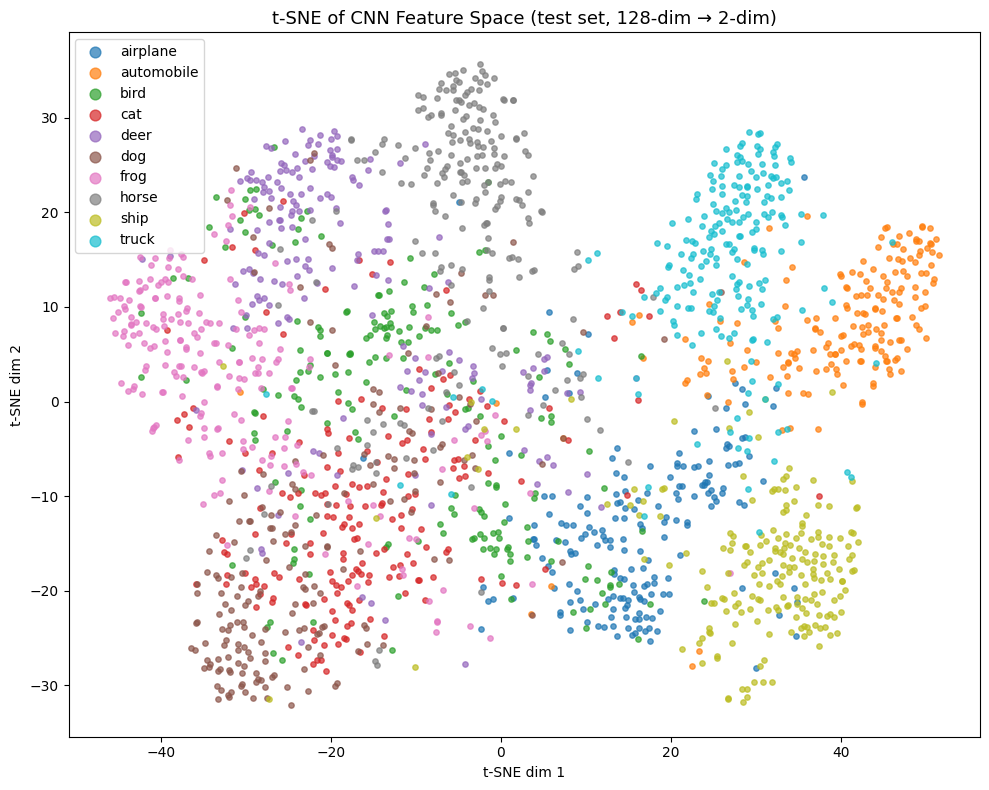


Well-separated clusters = the CNN has learned distinct representations per class.
Overlapping clusters (e.g. cat/dog, automobile/truck) = classes the CNN finds hard to separate.


In [25]:
# ── t-SNE visualization of CNN feature space ──────────────────────────────────
# t-SNE is slow: subsample to 2000 points for demonstration.

N_TSNE = 2000
np.random.seed(42)
idx = np.random.choice(len(test_feats), N_TSNE, replace=False)
feats_sample  = test_feats[idx]
labels_sample = test_labels[idx]

print(f'Running t-SNE on {N_TSNE} test samples (128-d CNN features → 2-d)...')
t0 = time.time()
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, verbose=0)
feats_2d = tsne.fit_transform(feats_sample)
print(f't-SNE done in {time.time()-t0:.1f}s')

# Plot colored by class
colors = plt.cm.get_cmap('tab10', 10)
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
for cls_idx, cls_name in enumerate(CLASSES):
    mask = labels_sample == cls_idx
    ax.scatter(feats_2d[mask, 0], feats_2d[mask, 1],
               c=[colors(cls_idx)], label=cls_name, s=15, alpha=0.7)
ax.set_title('t-SNE of CNN Feature Space (test set, 128-dim → 2-dim)', fontsize=13)
ax.legend(markerscale=2, loc='best')
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.show()

print()
print('Well-separated clusters = the CNN has learned distinct representations per class.')
print('Overlapping clusters (e.g. cat/dog, automobile/truck) = classes the CNN finds hard to separate.')

---
## Summary & Key Takeaways

| Concept | What you learned |
|---|---|
| **Normalization** | Always normalize inputs using training-set statistics; unnormalize before display |
| **Data augmentation** | Apply only to training set; increases effective dataset size |
| **Conv block anatomy** | Conv → BatchNorm → ReLU → MaxPool is the standard block |
| **Dimension tracing** | Always trace spatial dimensions manually before coding your model |
| **GAP vs Flatten** | Global Average Pooling is smaller and better-regularized |
| **Training loop** | zero_grad → forward → loss → backward → step, every batch |
| **model.eval()** | ALWAYS call before evaluation; disables Dropout and BN training mode |
| **LR scheduling** | CosineAnnealingLR reliably improves accuracy vs fixed LR |
| **Confusion matrix** | Reveals *which* classes are confused, not just overall accuracy |
| **Hooks** | `register_forward_hook` lets you intercept any intermediate tensor |
| **Grad-CAM** | Gradient × feature map → spatial explanation of predictions |
| **Transfer learning** | Feature extraction freezes backbone; fine-tuning updates all layers |
| **Differential LR** | Small LR for pretrained backbone, large LR for new head |
| **CNN as extractor** | GAP output is a compact, semantically meaningful image descriptor |
| **t-SNE** | Visualizes high-dimensional feature space in 2D for inspection |

---
> **You are now ready for Homework 4.** Good luck!
>
> *Remember: start early, save checkpoints often (`torch.save`), and come to office hours if you're stuck.*